In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

In [3]:
df_clean = df.copy()

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df_clean = df_clean.drop(columns=columns_to_drop)

df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

df_clean["Total Charges"] = (
    df_clean["Total Charges"]
    .fillna(0)
)

In [4]:
columns_to_drop_v2 = [
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Lat Long"
]

df_ml = df_clean.drop(columns=columns_to_drop_v2)

In [5]:
X = df_ml.drop("Churn Value", axis=1)
y = df_ml["Churn Value"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [8]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Catégorielles :", categorical_cols)
print("Numériques :", numerical_cols)

Catégorielles : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numériques : ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

In [10]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ]
)

In [11]:
logreg_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [12]:
y_pred_logreg = logreg_pipeline.predict(
    X_test
)

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    accuracy_score(
        y_test,
        y_pred_logreg
    )
)

print(
    classification_report(
        y_test,
        y_pred_logreg
    )
)

0.8034066713981547
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



# Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [16]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [17]:
y_pred_rf = rf_pipeline.predict(
    X_test
)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy : 0.794889992902768
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [19]:
y_proba = logreg_pipeline.predict_proba(
    X_test
)[:, 1]

In [20]:
y_proba[:10]

array([0.0749816 , 0.67794421, 0.09992757, 0.46501283, 0.03069806,
       0.61021131, 0.47174896, 0.04044317, 0.00116608, 0.38701383])

In [21]:
y_pred_40 = (
    y_proba >= 0.40
).astype(int)

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_40
    )
)

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409



Après entraînement d'une régression logistique, le modèle atteignait un recall de 57 % sur les clients susceptibles de quitter l'entreprise avec le seuil de décision par défaut (0.5).

Une analyse des probabilités de prédiction a permis d'ajuster le seuil à 0.4. Cette modification a augmenté le recall à 67 %, améliorant significativement la détection des clients à risque.

Cette expérience montre que l'optimisation du seuil de décision peut avoir un impact important sur la performance métier d'un modèle, parfois supérieur au simple changement d'algorithme.


# ROC Curve and AUC

In [23]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [24]:
y_proba = logreg_pipeline.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    y_proba
)

print("AUC :", round(auc, 4))

AUC : 0.8491


In [25]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

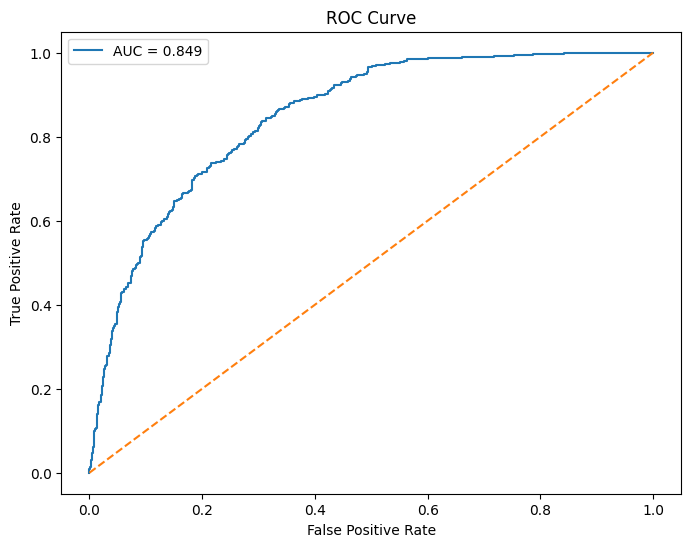

In [26]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# Model Comparison

In [27]:
from sklearn.metrics import roc_auc_score

y_proba_rf = rf_pipeline.predict_proba(
    X_test
)[:,1]

auc_rf = roc_auc_score(
    y_test,
    y_proba_rf
)

print("Random Forest AUC :", auc_rf)

Random Forest AUC : 0.8411041359890465


In [28]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.803,
        0.795
    ],
    "Precision": [
        0.65,
        0.64
    ],
    "Recall": [
        0.57,
        0.51
    ],
    "F1 Score": [
        0.61,
        0.57
    ],
    "AUC": [
        0.849,
        auc_rf
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.803,0.65,0.57,0.61,0.849000
1,Random Forest,0.795,0.64,0.51,0.57,0.841104


## Conclusion

La Logistic Regression a obtenu les meilleures performances
globales sur ce dataset :

- Accuracy : ...
- Recall : ...
- AUC : ...

Elle est retenue comme modèle final.

Le seuil de décision a ensuite été ajusté de 0.5 à 0.4,
permettant d'améliorer le recall des churners de 57 % à 67 %.

# Modeling Conclusion

Two machine learning models were evaluated for customer churn prediction:

* Logistic Regression
* Random Forest

The Logistic Regression model achieved the best overall performance:

| Metric    | Score |
| --------- | ----- |
| Accuracy  | 80.3% |
| Precision | 65%   |
| Recall    | 57%   |
| F1 Score  | 61%   |
| AUC       | 0.849 |

The Random Forest model produced slightly lower results across all evaluation metrics.

An additional threshold optimization was performed on the Logistic Regression model. By reducing the decision threshold from 0.50 to 0.40, recall increased from 57% to 67%, allowing the model to detect a larger proportion of customers at risk of churn.

The Logistic Regression pipeline was therefore selected as the final model for deployment.


In [29]:
import joblib

joblib.dump(
    logreg_pipeline,
    "../models/churn_pipeline.joblib"
)

['../models/churn_pipeline.joblib']

In [30]:
loaded_pipeline = joblib.load(
    "../models/churn_pipeline.joblib"
)

loaded_pipeline.predict(
    X_test.head(5)
)

array([0, 1, 0, 0, 0])